In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import wooldridge as woo
import pandas as pd
import wooldridge as woo

### Part A

In [3]:
def generate_data(N, beta_0=0, alpha_0=-1, sigma_sq=1):

    # Generate random variables
    p = np.random.normal(0, 1, N)            
    z = np.random.normal(0, np.sqrt(sigma_sq), N)   
    u = np.random.normal(0, 1, N)                
    v = np.random.normal(0, 1, N)
    
    # Calculate indirect utility
    indirect_utility = beta_0 + (alpha_0 + z) * p + u
    
    # Generate binary outcome: y_i = 1 if indirect utility >= outside option
    Y = (indirect_utility >= v).astype(int)
    
    # Construct design matrix: [intercept, price, demand_shifter]
    D = np.column_stack([np.ones(N), p, z])
    
    return Y, D, u

### Part B

In [11]:
def plot_avg_y(N, avg_y, beta_0_values, alpha_0=-1, sigma_sq=1):
    plt.figure(figsize=(10, 6))
    plt.plot(beta_0_values, avg_y, 'b-', linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Purchase rate = 0.5')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='β₀ = 0')
    plt.xlabel('β₀ (Baseline Utility)', fontsize=12)
    plt.ylabel('Average Purchase Rate (E[y_i])', fontsize=12)
    plt.title('Purchase Rate vs. Baseline Utility Parameter', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('purchase_rate_vs_beta0.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print some statistics
    print("=" * 60)
    print("Purchase Rate Analysis")
    print("=" * 60)
    print(f"Parameters: α₀ = {alpha_0}, σ² = {sigma_sq}, N = {N}")
    print(f"\nPurchase rate when β₀ = -2.0: {avg_y[0]:.4f}")
    print(f"Purchase rate when β₀ =  0.0: {avg_y[20]:.4f}")
    print(f"Purchase rate when β₀ =  2.0: {avg_y[-1]:.4f}")
    print(f"\nβ₀ value closest to 50% purchase rate: {beta_0_values[np.argmin(np.abs(np.array(avg_y) - 0.5))]:.1f}")

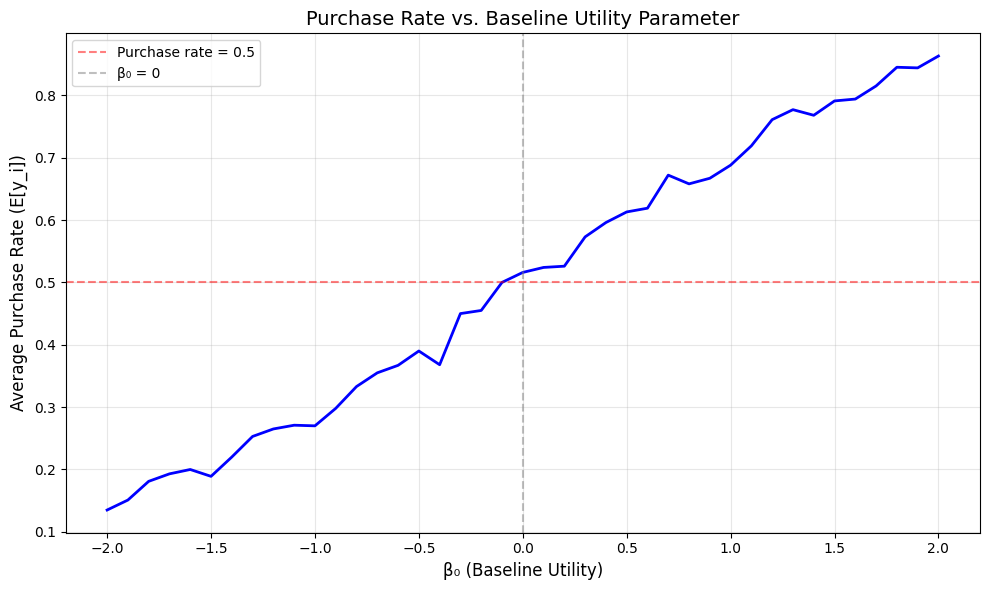

Purchase Rate Analysis
Parameters: α₀ = -1, σ² = 1, N = 1000

Purchase rate when β₀ = -2.0: 0.1350
Purchase rate when β₀ =  0.0: 0.5160
Purchase rate when β₀ =  2.0: 0.8630

β₀ value closest to 50% purchase rate: -0.1


In [21]:
N = 1000

# Vary beta_0 from -2 to 2 in steps of 0.1
beta_0_values = np.arange(-2, 2.1, 0.1)
avg_y = []

for beta_0 in beta_0_values:
    Y, D, U = generate_data(N, beta_0)
    avg_y.append(Y.mean())

plot_avg_y(N, avg_y, beta_0_values)

### Part C

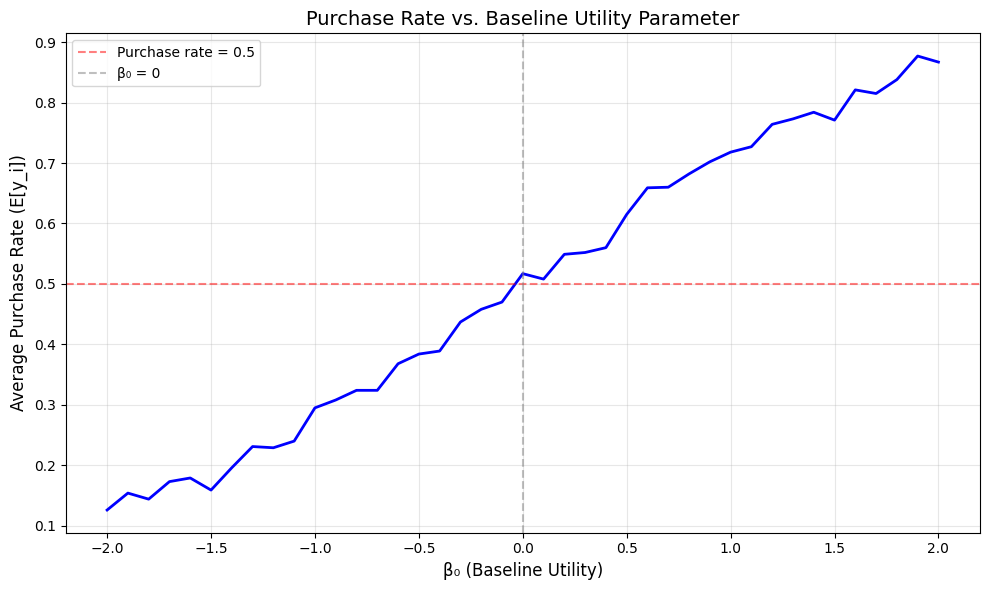

Purchase Rate Analysis
Parameters: α₀ = -1, σ² = 0.1, N = 1000

Purchase rate when β₀ = -2.0: 0.1260
Purchase rate when β₀ =  0.0: 0.5170
Purchase rate when β₀ =  2.0: 0.8670

β₀ value closest to 50% purchase rate: 0.1


In [22]:
N = 1000
sigma_sq =0.1

# Vary beta_0 from -2 to 2 in steps of 0.1
beta_0_values = np.arange(-2, 2.1, 0.1)
avg_y = []

for beta_0 in beta_0_values:
    Y, D, U = generate_data(N=N, beta_0=beta_0, sigma_sq=sigma_sq)
    avg_y.append(Y.mean())

plot_avg_y(N=N, avg_y=avg_y, beta_0_values=beta_0_values, sigma_sq=sigma_sq)